# Test-Set Model Comparison and Forecast Analysis

## Overview

This notebook consolidates the final test-set outputs from the benchmark, machine learning, and regime-aware volatility forecasting models. It compares GARCH, SVR, LSTM-SVR, RF-SVR, HMM-SVR, neutral-SVR, and oracle-SVR forecasts on a common realized variance scale.

The purpose of the notebook is to provide the final cross-model performance analysis for the project. The object being evaluated is one-day-ahead Bitcoin realized variance, using each model's exported test predictions and the corresponding realized variance values.

The notebook is structured as follows:

1. Load required libraries and define shared evaluation metrics, including RMSE, MSE, MAPE-style absolute error, and QLIKE.
2. Import test-set forecast files from the GARCH, SVR, LSTM-SVR, RF-SVR, HMM-SVR, neutral, and oracle model workflows.
3. Convert log-variance predictions back to variance scale where required.
4. Compute and tabulate performance metrics for all models.
5. Prepare aligned forecast series by date for fair pairwise model comparison.
6. Run Diebold-Mariano tests to assess whether forecast loss differences are statistically significant.
7. Evaluate directional accuracy by checking whether each model predicts the direction of day-to-day variance changes.
8. Generate combined plots comparing actual realized variance against model forecasts over the test period.


In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [2]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def mse(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean((y_true[mask] - y_pred[mask]) ** 2)

def mape(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask])))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 

In [3]:
# test results from garch
test_garch = pd.read_csv('benchmark garch/garch.csv')
test_garch['var_garch_bench'] = np.exp(test_garch['var_garch_bench'])
test_garch['actual_var'] = np.exp(test_garch['actual_var'])

garch_rmse = rmse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mse = mse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mape = mape(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_qlike = qlike(test_garch['actual_var'], test_garch['var_garch_bench'])

garch_rmse, garch_mse, garch_mape, garch_qlike

(np.float64(0.0006515314758416832),
 np.float64(4.244932640124419e-07),
 np.float64(0.00040337506799161763),
 np.float64(0.43333737612205614))

In [4]:
# test results from svr
test_svr = pd.read_csv('SVR/results/svr_test_results.csv')

svr_rmse = rmse(test_svr['actual_var'], test_svr['pred_var'])
svr_mse = mse(test_svr['actual_var'], test_svr['pred_var'])
svr_mape = mape(test_svr['actual_var'], test_svr['pred_var'])
svr_qlike = qlike(test_svr['actual_var'], test_svr['pred_var'])

svr_rmse, svr_mse, svr_mape, svr_qlike

(np.float64(0.0006181252597298834),
 np.float64(3.8207883671613576e-07),
 np.float64(0.00038308088566718163),
 np.float64(0.4110958060087798))

In [5]:
# test result from lstm-svr new
test_lstmsvr = pd.read_csv('lstm-regimeaware/results/lstm-svr3.csv')
test_lstmsvr['var_svr'] = np.exp(test_lstmsvr['log_var_svr'])
test_lstmsvr['actual_var'] = np.exp(test_lstmsvr['actual_log_var'])

lstmsvr_rmse = rmse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mse = mse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mape = mape(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_qlike = qlike(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])

lstmsvr_rmse, lstmsvr_mse, lstmsvr_mape, lstmsvr_qlike


(np.float64(0.0006662977250219346),
 np.float64(4.439526583694056e-07),
 np.float64(0.0003683045281214931),
 np.float64(0.5250502891219616))

In [6]:
# test results from rf-svr new
test_rfsvr = pd.read_csv('rf-regimeaware/results/rf-svr(withoutcov)_results.csv')
test_rfsvr['var_svr'] = np.exp(test_rfsvr['log_var_svr'])
test_rfsvr['actual_var'] = np.exp(test_rfsvr['actual_log_var'])

rfsvr_rmse = rmse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mse = mse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mape = mape(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_qlike = qlike(test_rfsvr['actual_var'], test_rfsvr['var_svr'])

rfsvr_rmse, rfsvr_mse, rfsvr_mape, rfsvr_qlike

(np.float64(0.0006093319379597776),
 np.float64(3.712854106178183e-07),
 np.float64(0.0003740253640299656),
 np.float64(0.3856721731928747))

In [7]:
# test results from HMM-svr
test_hmmsvr = pd.read_csv('2_step_hmm_model/results/hmm_svrl_revised_test_results.csv')

hmmsvr_rmse = rmse(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_mse = mse(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_mape = mape(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_qlike = qlike(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])

hmmsvr_rmse, hmmsvr_mse, hmmsvr_mape, hmmsvr_qlike


(np.float64(0.0006464083384380918),
 np.float64(4.1784374000229467e-07),
 np.float64(0.00038760568774427994),
 np.float64(0.45196434264944063))

In [8]:
test_neutral = pd.read_csv('error_analysis/neutral_results.csv')
test_neutral['var_svr'] = np.exp(test_neutral['log_var_svr'])
test_neutral['actual_var'] = np.exp(test_neutral['actual_log_var'])

neutral_rmse = rmse(test_neutral['actual_var'], test_neutral['var_svr'])
neutral_mse = mse(test_neutral['actual_var'], test_neutral['var_svr'])
neutral_mape = mape(test_neutral['actual_var'], test_neutral['var_svr'])
neutral_qlike = qlike(test_neutral['actual_var'], test_neutral['var_svr'])

neutral_rmse, neutral_mse, neutral_mape, neutral_qlike



(np.float64(0.000626065642938846),
 np.float64(3.9195818926843064e-07),
 np.float64(0.00036692901647952727),
 np.float64(0.396908839430479))

In [9]:
test_oracle = pd.read_csv('error_analysis/oracle_results.csv')
test_oracle['var_svr'] = np.exp(test_oracle['log_var_svr'])
test_oracle['actual_var'] = np.exp(test_oracle['actual_log_var'])

oracle_rmse = rmse(test_oracle['actual_var'], test_oracle['var_svr'])
oracle_mse = mse(test_oracle['actual_var'], test_oracle['var_svr'])
oracle_mape = mape(test_oracle['actual_var'], test_oracle['var_svr'])
oracle_qlike = qlike(test_oracle['actual_var'], test_oracle['var_svr'])

oracle_rmse, oracle_mse, oracle_mape, oracle_qlike

(np.float64(0.0005951171461590439),
 np.float64(3.541644176524848e-07),
 np.float64(0.00028729031663028584),
 np.float64(0.2594273706175169))

In [10]:
# put all into a df 

results_df = pd.DataFrame({
    "Model": ["GARCH", "SVR", "LSTM-SVR", "RF-SVR", "HMM-SVR", "Neutral-SVR", "Oracle-SVR"],
    "RMSE": [garch_rmse, svr_rmse, lstmsvr_rmse, rfsvr_rmse, hmmsvr_rmse, neutral_rmse, oracle_rmse],
    "MSE":  [garch_mse,  svr_mse,  lstmsvr_mse,  rfsvr_mse, hmmsvr_mse, neutral_mse, oracle_mse],
    "MAPE": [garch_mape, svr_mape, lstmsvr_mape, rfsvr_mape, hmmsvr_mape, neutral_mape, oracle_mape],
    "QLIKE":[garch_qlike, svr_qlike, lstmsvr_qlike, rfsvr_qlike, hmmsvr_qlike, neutral_qlike, oracle_qlike]
})

print(results_df)

         Model      RMSE           MSE      MAPE     QLIKE
0        GARCH  0.000652  4.244933e-07  0.000403  0.433337
1          SVR  0.000618  3.820788e-07  0.000383  0.411096
2     LSTM-SVR  0.000666  4.439527e-07  0.000368  0.525050
3       RF-SVR  0.000609  3.712854e-07  0.000374  0.385672
4      HMM-SVR  0.000646  4.178437e-07  0.000388  0.451964
5  Neutral-SVR  0.000626  3.919582e-07  0.000367  0.396909
6   Oracle-SVR  0.000595  3.541644e-07  0.000287  0.259427


In [11]:
# put all into a df 

results_df = pd.DataFrame({
    "Model": ["LSTM-SVR", "RF-SVR", "HMM-SVR", "Neutral-SVR", "Oracle-SVR"],
    "RMSE": [lstmsvr_rmse, rfsvr_rmse, hmmsvr_rmse, neutral_rmse, oracle_rmse],
    "MSE":  [lstmsvr_mse,  rfsvr_mse,  hmmsvr_mse,  neutral_mse, oracle_mse],
    "MAPE": [lstmsvr_mape, rfsvr_mape, hmmsvr_mape, neutral_mape, oracle_mape],
    "QLIKE":[lstmsvr_qlike, rfsvr_qlike, hmmsvr_qlike, neutral_qlike, oracle_qlike]
})

print(results_df)

         Model      RMSE           MSE      MAPE     QLIKE
0     LSTM-SVR  0.000666  4.439527e-07  0.000368  0.525050
1       RF-SVR  0.000609  3.712854e-07  0.000374  0.385672
2      HMM-SVR  0.000646  4.178437e-07  0.000388  0.451964
3  Neutral-SVR  0.000626  3.919582e-07  0.000367  0.396909
4   Oracle-SVR  0.000595  3.541644e-07  0.000287  0.259427


In [12]:
# Prepare data for DM test

# test_garch: drop error column, keep date and var_garch_bench
dm_garch = test_garch[['date', 'var_garch_bench']].copy()
dm_garch.columns = ['date', 'pred_var_garch']

# test_svr: rename pred_var to pred_var_svr, keep only date and pred_var_svr
dm_svr = test_svr[['date', 'pred_var']].copy()
dm_svr.columns = ['date', 'pred_var_svr']

# test_lstmsvr: rename var_svr to pred_var_lstmsvr, keep only date and pred_var_lstmsvr
dm_lstmsvr = test_lstmsvr[['date', 'var_svr']].copy()
dm_lstmsvr.columns = ['date', 'pred_var_lstmsvr']

# test_rfsvr: rename var_svr to pred_var_rfsvr, keep pred_var_rfsvr and date
dm_rfsvr = test_rfsvr[['date', 'var_svr']].copy()
dm_rfsvr.columns = ['date', 'pred_var_rfsvr']

# test_hmmsvr: rename forecast_var to pred_hmmsvr, keep pred_hmmsvr and date
dm_hmmsvr = test_hmmsvr[['date', 'forecast_var']].copy()
dm_hmmsvr.columns = ['date', 'pred_hmmsvr']

# Create merged dataframe with inner join on date
dm_combined = dm_garch.copy()
dm_combined = dm_combined.merge(dm_svr, on='date', how='inner')
dm_combined = dm_combined.merge(dm_lstmsvr, on='date', how='inner')
dm_combined = dm_combined.merge(dm_rfsvr, on='date', how='inner')
dm_combined = dm_combined.merge(dm_hmmsvr, on='date', how='inner')

print(f"Combined DM data shape: {dm_combined.shape}")
print(dm_combined.head())

Combined DM data shape: (469, 6)
         date  pred_var_garch  pred_var_svr  pred_var_lstmsvr  pred_var_rfsvr  \
0  2024-10-20        0.000666      0.000223          0.000407        0.000257   
1  2024-10-21        0.000697      0.000396          0.000652        0.000458   
2  2024-10-22        0.000685      0.000632          0.000625        0.000665   
3  2024-10-23        0.000546      0.000491          0.000431        0.000599   
4  2024-10-24        0.000604      0.000472          0.000184        0.000384   

   pred_hmmsvr  
0     0.000243  
1     0.000380  
2     0.000570  
3     0.000432  
4     0.000422  


In [13]:
from scipy import stats
import numpy as np

def diebold_mariano_test(actual, pred_benchmark, pred_alternative, loss_function='mse', max_lag=0):
    actual = np.asarray(actual, dtype=float)
    pred_benchmark = np.asarray(pred_benchmark, dtype=float)
    pred_alternative = np.asarray(pred_alternative, dtype=float)

    mask = np.isfinite(actual) & np.isfinite(pred_benchmark) & np.isfinite(pred_alternative)

    actual = actual[mask]
    pred_benchmark = pred_benchmark[mask]
    pred_alternative = pred_alternative[mask]

    if loss_function == 'mse':
        loss_bench = (actual - pred_benchmark) ** 2
        loss_alt = (actual - pred_alternative) ** 2
    elif loss_function == 'mae':
        loss_bench = np.abs(actual - pred_benchmark)
        loss_alt = np.abs(actual - pred_alternative)
    elif loss_function == 'mape':
        loss_bench = np.abs((actual - pred_benchmark) / actual)
        loss_alt = np.abs((actual - pred_alternative) / actual)
    elif loss_function == 'qlike':
        eps = 1e-10
        pred_benchmark = np.maximum(pred_benchmark, eps)
        pred_alternative = np.maximum(pred_alternative, eps)
        actual = np.maximum(actual, eps)

        loss_bench = actual / pred_benchmark - np.log(actual / pred_benchmark) - 1
        loss_alt = actual / pred_alternative - np.log(actual / pred_alternative) - 1
    else:
        raise ValueError(f"Unknown loss function: {loss_function}")

    loss_diff = loss_bench - loss_alt
    mean_diff = np.mean(loss_diff)
    n = len(loss_diff)

    var_diff = np.mean((loss_diff - mean_diff) ** 2)

    for lag in range(1, max_lag + 1):
        gamma_lag = np.mean(
            (loss_diff[lag:] - mean_diff) * 
            (loss_diff[:-lag] - mean_diff)
        )
        var_diff += 2 * (1 - lag / (max_lag + 1)) * gamma_lag

    if var_diff <= 0:
        var_diff = np.var(loss_diff)

    dm_stat = mean_diff / np.sqrt(var_diff / n) if var_diff > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return dm_stat, p_value, mean_diff

In [14]:
# DM Test 1: GARCH (benchmark) vs SVR, LSTM-SVR, RF-SVR, HMM-SVR
# Get actual variance (from original data)
actual_var = test_garch['actual_var'].values
garch_pred = dm_garch['pred_var_garch'].values

print("=" * 80)
print("DM Test 1: GARCH (Benchmark) vs Other Models (Lag = 0)")
print("=" * 80)

# Store models in a dictionary for cleaner looping
models = {
    "SVR": dm_combined['pred_var_svr'].values,
    "LSTM-SVR": dm_combined['pred_var_lstmsvr'].values,
    "RF-SVR": dm_combined['pred_var_rfsvr'].values,
    "HMM-SVR": dm_combined['pred_hmmsvr'].values
}

# Run DM tests
for model_name, pred in models.items():
    dm_stat, p_value, mean_diff = diebold_mariano_test(
        actual_var,
        garch_pred,
        pred,
        loss_function='mse',
        max_lag=0  
    )
    
    print(f"\nGARCH vs {model_name} (MSE Loss):")
    print(f"  DM Statistic: {dm_stat:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Mean Loss Difference: {mean_diff:.6f}")
    print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

DM Test 1: GARCH (Benchmark) vs Other Models (Lag = 0)

GARCH vs SVR (MSE Loss):
  DM Statistic: 1.603440
  P-value: 0.108837
  Mean Loss Difference: 0.000000
  Significant at 5%: No

GARCH vs LSTM-SVR (MSE Loss):
  DM Statistic: -1.008279
  P-value: 0.313320
  Mean Loss Difference: -0.000000
  Significant at 5%: No

GARCH vs RF-SVR (MSE Loss):
  DM Statistic: 2.169117
  P-value: 0.030074
  Mean Loss Difference: 0.000000
  Significant at 5%: Yes

GARCH vs HMM-SVR (MSE Loss):
  DM Statistic: 0.296547
  P-value: 0.766812
  Mean Loss Difference: 0.000000
  Significant at 5%: No


In [15]:
# DM Test 2: RF-SVR (benchmark) vs LSTM-SVR and HMM-SVR

rfsvr_pred = dm_combined['pred_var_rfsvr'].values

print("\n" + "=" * 80)
print("DM Test 2: RF-SVR (Benchmark) vs LSTM-SVR and HMM-SVR (Lag = 0)")
print("=" * 80)

models = {
    "LSTM-SVR": dm_combined['pred_var_lstmsvr'].values,
    "HMM-SVR": dm_combined['pred_hmmsvr'].values
}

for model_name, pred in models.items():
    dm_stat, p_value, mean_diff = diebold_mariano_test(
        actual_var,
        rfsvr_pred,
        pred,
        loss_function='mse',
        max_lag=0
    )

    print(f"\nRF-SVR vs {model_name} (MSE Loss):")
    print(f"  DM Statistic: {dm_stat:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Mean Loss Difference: {mean_diff:.6f}")
    print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")


DM Test 2: RF-SVR (Benchmark) vs LSTM-SVR and HMM-SVR (Lag = 0)

RF-SVR vs LSTM-SVR (MSE Loss):
  DM Statistic: -2.450010
  P-value: 0.014285
  Mean Loss Difference: -0.000000
  Significant at 5%: Yes

RF-SVR vs HMM-SVR (MSE Loss):
  DM Statistic: -1.592852
  P-value: 0.111193
  Mean Loss Difference: -0.000000
  Significant at 5%: No


In [16]:
# Directional accuracy test (hit rate)

actual_var = test_garch[['date', 'actual_var']].copy()
hit_rate_df = actual_var.merge(dm_combined, on='date', how='inner')

# 1) Actual day-to-day change in realized volatility
hit_rate_df["actual_change"] = hit_rate_df["actual_var"].diff()

# 2) Forecasted day-to-day change for each model
model_cols = {
    "GARCH": "pred_var_garch",
    "SVR": "pred_var_svr",
    "LSTM-SVR": "pred_var_lstmsvr",
    "RF-SVR": "pred_var_rfsvr",
    "HMM-SVR": "pred_hmmsvr"
}

results = []

for model_name, col in model_cols.items():
    pred_change_col = f"{col}_change"
    hit_col = f"{col}_hit"
    
    # Predicted day-to-day change
    hit_rate_df[pred_change_col] = hit_rate_df[col].diff()
    
    # Keep only rows where both actual and predicted changes are non-missing
    temp = hit_rate_df[["actual_change", pred_change_col]].dropna().copy()
    
    # Optional: exclude zero-change cases since direction is ambiguous
    temp = temp[(temp["actual_change"] != 0) & (temp[pred_change_col] != 0)]
    
    # Hit = sign of predicted change matches sign of actual change
    temp[hit_col] = np.sign(temp["actual_change"]) == np.sign(temp[pred_change_col])
    
    n_obs = len(temp)
    n_hits = temp[hit_col].sum()
    hit_rate = n_hits / n_obs if n_obs > 0 else np.nan
    
    results.append({
        "Model": model_name,
        "Hits": int(n_hits) if pd.notna(hit_rate) else np.nan,
        "Total Valid Observations": n_obs,
        "Hit Rate": hit_rate,
        "Hit Rate (%)": hit_rate * 100 if pd.notna(hit_rate) else np.nan
    })

# 3) Results table
hit_rate_results = pd.DataFrame(results)

# Format for display
hit_rate_results["Hit Rate"] = hit_rate_results["Hit Rate"].round(4)
hit_rate_results["Hit Rate (%)"] = hit_rate_results["Hit Rate (%)"].round(2)

print(hit_rate_results)


      Model  Hits  Total Valid Observations  Hit Rate  Hit Rate (%)
0     GARCH   225                       468    0.4808         48.08
1       SVR   200                       468    0.4274         42.74
2  LSTM-SVR   210                       468    0.4487         44.87
3    RF-SVR   223                       468    0.4765         47.65
4   HMM-SVR   212                       468    0.4530         45.30


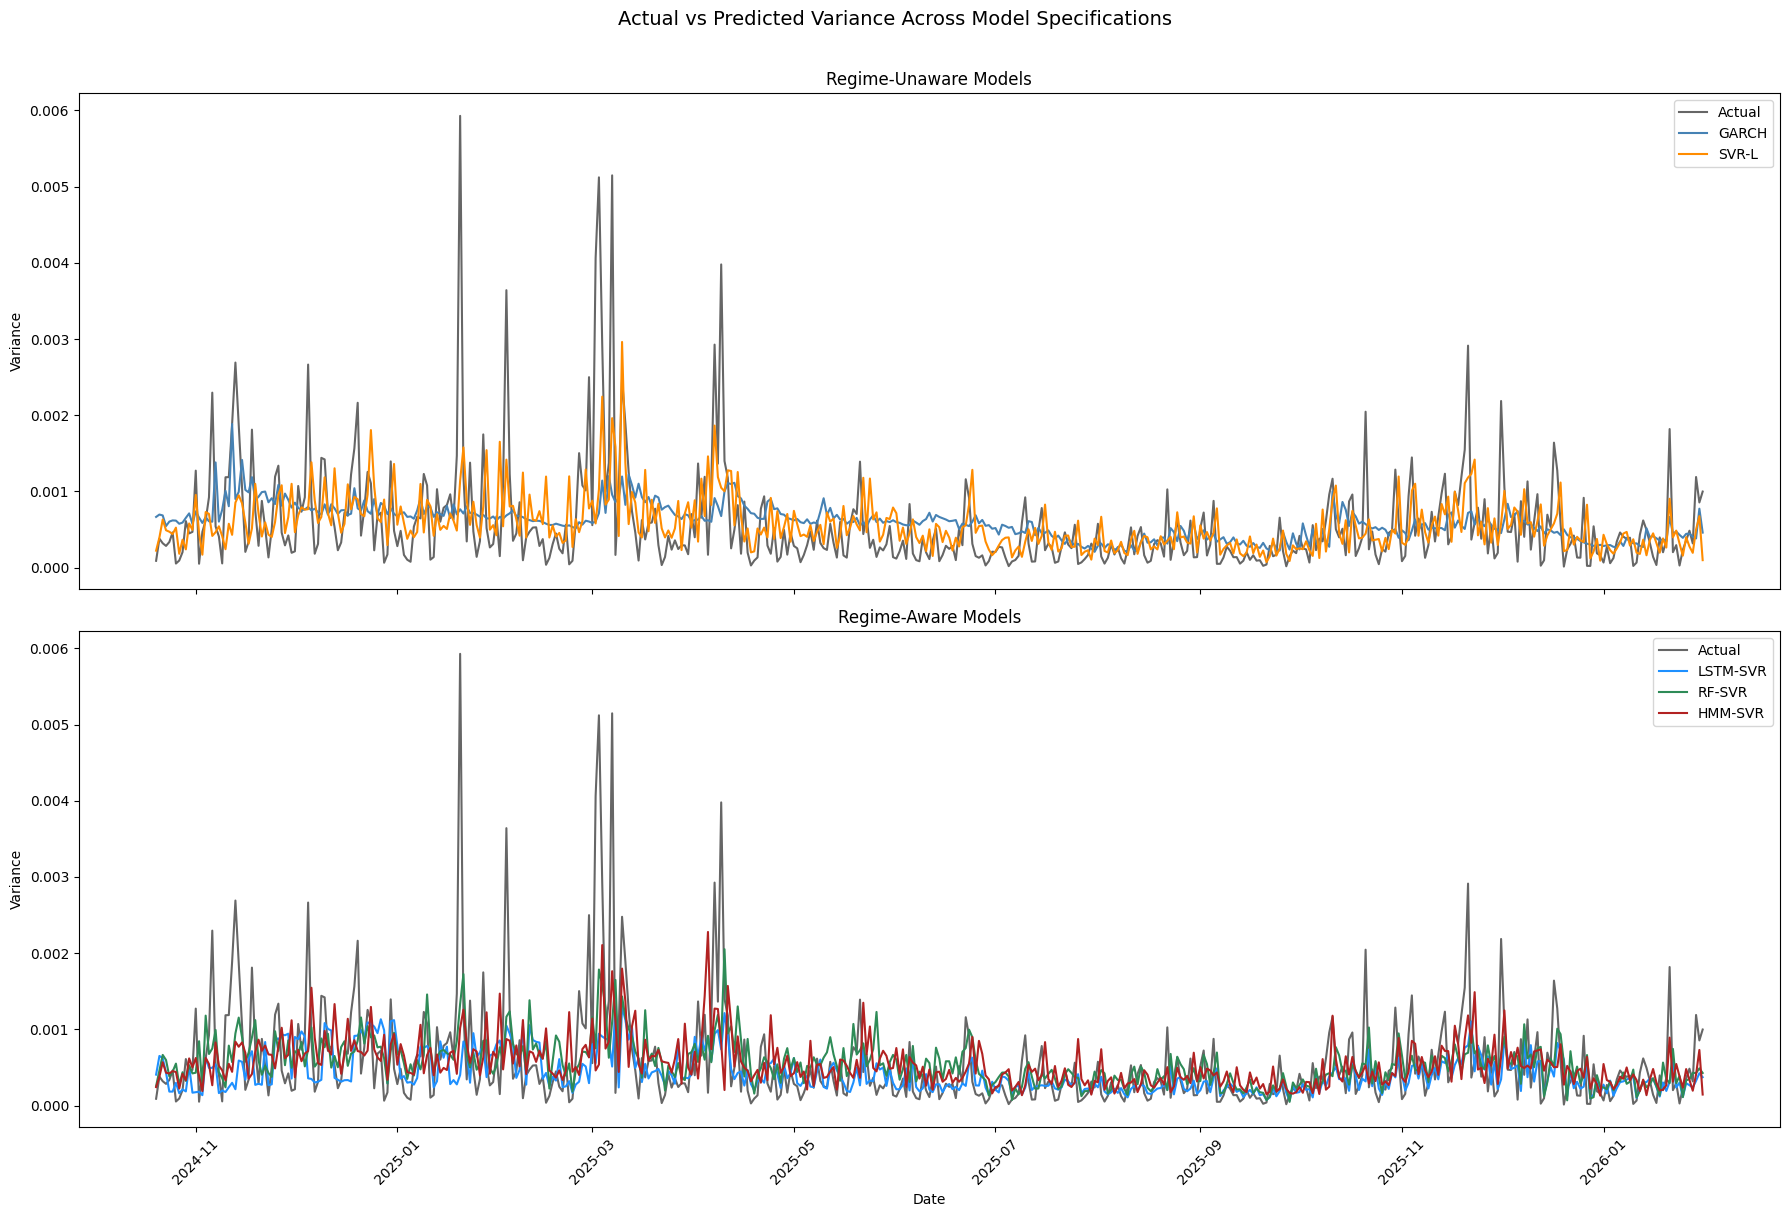

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read results
# -----------------------------
test_garch = pd.read_csv("benchmark garch/garch.csv")
test_svr = pd.read_csv("SVR/results/svr_test_results.csv")
test_lstmsvr = pd.read_csv("lstm-regimeaware/results/lstm-svr3.csv")
test_rfsvr = pd.read_csv("rf-regimeaware/results/rf-svr(withoutcov)_results.csv")
test_hmmsvr = pd.read_csv('2_step_hmm_model/results/hmm_svrl_revised_test_results.csv')

# -----------------------------
# 2. Convert to variance scale
# -----------------------------
test_garch["actual_var"] = np.exp(test_garch["actual_var"])
test_garch["pred_garch"] = np.exp(test_garch["var_garch_bench"])

test_svr["pred_svr"] = test_svr["pred_var"]

test_lstmsvr["actual_var"] = np.exp(test_lstmsvr["actual_log_var"])
test_lstmsvr["pred_lstmsvr"] = np.exp(test_lstmsvr["log_var_svr"])

test_rfsvr["actual_var"] = np.exp(test_rfsvr["actual_log_var"])
test_rfsvr["pred_rfsvr"] = np.exp(test_rfsvr["log_var_svr"])

# -----------------------------
# 3. Keep only needed columns
#    adjust "date" 
# -----------------------------
garch_df = test_garch[["date", "actual_var", "pred_garch"]].copy()
svr_df = test_svr[["date", "actual_var", "pred_svr"]].copy()
lstm_df = test_lstmsvr[["date", "actual_var", "pred_lstmsvr"]].copy()
rf_df = test_rfsvr[["date", "actual_var", "pred_rfsvr"]].copy()
hmm_df = test_hmmsvr[["date", "actual_var", "forecast_var"]].copy()
hmm_df['date'] = pd.to_datetime(hmm_df['date']) 

# -----------------------------
# 4. Convert dates
# -----------------------------
for df in [garch_df, svr_df, lstm_df, rf_df]:
    df["date"] = pd.to_datetime(df["date"])

# -----------------------------
# 5. Merge everything on date
# -----------------------------
plot_df = (
    garch_df[["date", "actual_var", "pred_garch"]]
    .merge(svr_df[["date", "pred_svr"]], on="date", how="inner")
    .merge(lstm_df[["date", "pred_lstmsvr"]], on="date", how="inner")
    .merge(rf_df[["date", "pred_rfsvr"]], on="date", how="inner")
    .merge(hmm_df[["date", "forecast_var"]].rename(columns={"forecast_var": "pred_hmmsvr"}), on="date", how="inner")
    .sort_values("date")
)

# -----------------------------
# 6. Plot
# -----------------------------
# To avoid cluttered plots, we split into two panels: regime-unaware (GARCH, SVR)
# and regime-aware (LSTM-SVR, RF-SVR, HMM-SVR)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Panel 1: Regime-unaware
ax1.plot(plot_df["date"], plot_df["actual_var"], label="Actual", color="black", linewidth=1.5, alpha=0.6)
ax1.plot(plot_df["date"], plot_df["pred_garch"], label="GARCH", color="steelblue")
ax1.plot(plot_df["date"], plot_df["pred_svr"], label="SVR-L", color="darkorange")
ax1.set_title("Regime-Unaware Models")
ax1.set_ylabel("Variance")
ax1.legend()

# Panel 2: Regime-aware
ax2.plot(plot_df["date"], plot_df["actual_var"], label="Actual", color="black", linewidth=1.5, alpha=0.6)
ax2.plot(plot_df["date"], plot_df["pred_lstmsvr"], label="LSTM-SVR", color="dodgerblue")
ax2.plot(plot_df["date"], plot_df["pred_rfsvr"], label="RF-SVR", color="seagreen")
ax2.plot(plot_df["date"], plot_df["pred_hmmsvr"], label="HMM-SVR", color="firebrick")
ax2.set_title("Regime-Aware Models")
ax2.set_ylabel("Variance")
ax2.set_xlabel("Date")
ax2.legend()

plt.xticks(rotation=45)
plt.suptitle("Actual vs Predicted Variance Across Model Specifications", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()